In [1]:
%pip install -q transformers huggingface_hub
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Build-a-transformer

In this section, you will implement a transformer language model layer by layer, then use it to generate (hopefully) coherent text.

To understand how these layers work, please check out our guide to transformers from [nlp course for you -> transformers](https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html#transformer_intro).

First, we download pre-trained weights for the [GPT2 model by OpenAI](https://openai.com/research/better-language-models) - a prominent model from 2019.

Idea & code by: Ilya Beletsky


In [2]:
from huggingface_hub import hf_hub_download
state_dict = torch.load(hf_hub_download("gpt2", filename="pytorch_model.bin"))
for key, value in tuple(state_dict.items()):
    if key.startswith('h.') and key.endswith('.weight') and value.ndim == 2:
        value.transpose_(1, 0)  # <-- for compatibility with modern PyTorch modules
    if key.startswith('h.') and key.endswith('.attn.bias') and value.ndim == 4:
        state_dict.pop(key)  # <-- triangular binar masks, not needed in this code

print('Weights:', repr(sorted(state_dict.keys()))[:320], '...')
#repr để chuyển list thành str để slicing lấy 320 kí tự đầu 

Weights: ['h.0.attn.c_attn.bias', 'h.0.attn.c_attn.weight', 'h.0.attn.c_proj.bias', 'h.0.attn.c_proj.weight', 'h.0.ln_1.bias', 'h.0.ln_1.weight', 'h.0.ln_2.bias', 'h.0.ln_2.weight', 'h.0.mlp.c_fc.bias', 'h.0.mlp.c_fc.weight', 'h.0.mlp.c_proj.bias', 'h.0.mlp.c_proj.weight', 'h.1.attn.c_attn.bias', 'h.1.attn.c_attn.weight', 'h.1. ...


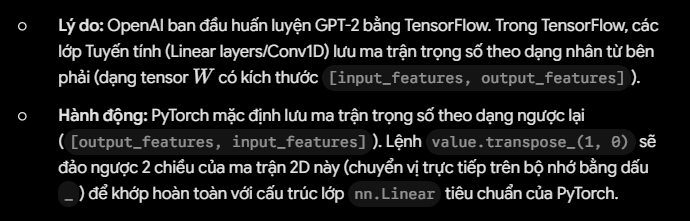


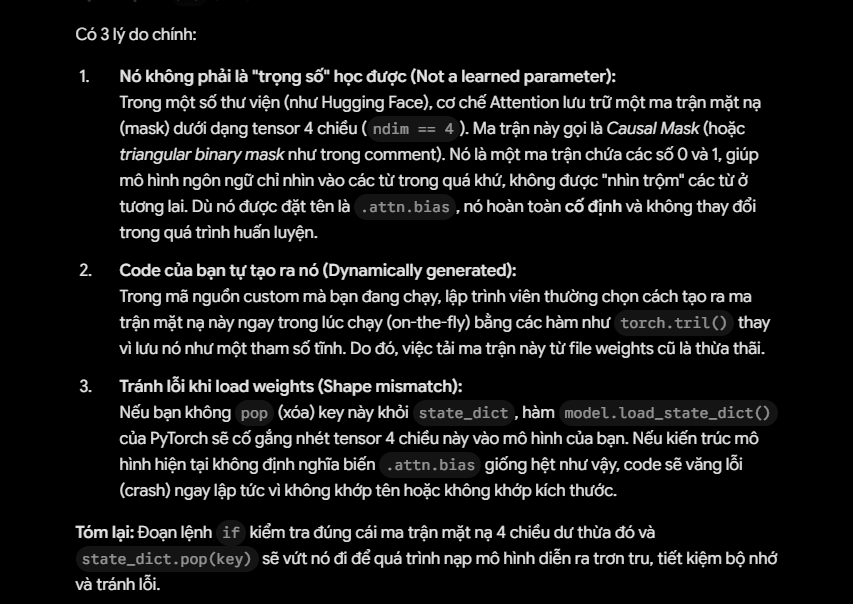


In the next few cells, we shall implement the model layer by layer to make use of those weights.

As you might recall, transformers contain two main layer types: attention and fully-connected layers.

The fully connected layers are by far easier to understand, so we shall begin there:

Please implement fully-connected layer **without residual or layer normalization** (we'll add those in a bit).


In [3]:
import math
import torch
import torch.nn as nn

class GeLUThatWasUsedInGPT2(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)))

class FullyConnected(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.c_fc = nn.Linear(dim, 4  * dim)
        self.gelu = GeLUThatWasUsedInGPT2()
        self.c_proj = nn.Linear(4 * dim, dim)

    def forward(self, x):
        # x.shape = [batch_size, seq_length, dim]
            # batch_size: Số lượng câu/đoạn văn đang xử lý cùng lúc.
            # seq_length: Số lượng từ (tokens) trong mỗi câu.
            # dim: Kích thước vector biểu diễn (embedding dimension) của mỗi từ (ví dụ: ở GPT-2 cỡ nhỏ, dim = 768).
        # 1. Project up to the wider hidden dimension (4 * dim)
        x = self.c_fc(x) # đẩy không gian lên nhiều chiều giúp mô hình thêm bộ nhớ để phân tích bóc tách đặc trưng phức tạp
        # Shape: [batch_size, seq_length,4* dim]

        # 2. Apply the GeLU activation function
        x = self.gelu(x)
        # Shape: [batch_size, seq_length,4* dim]

        # 3. Project back down to the original dimension (dim)
        x = self.c_proj(x) # nén kích thước về lại ban đầu
        # Shape: [batch_size, seq_length, dim]
        return x

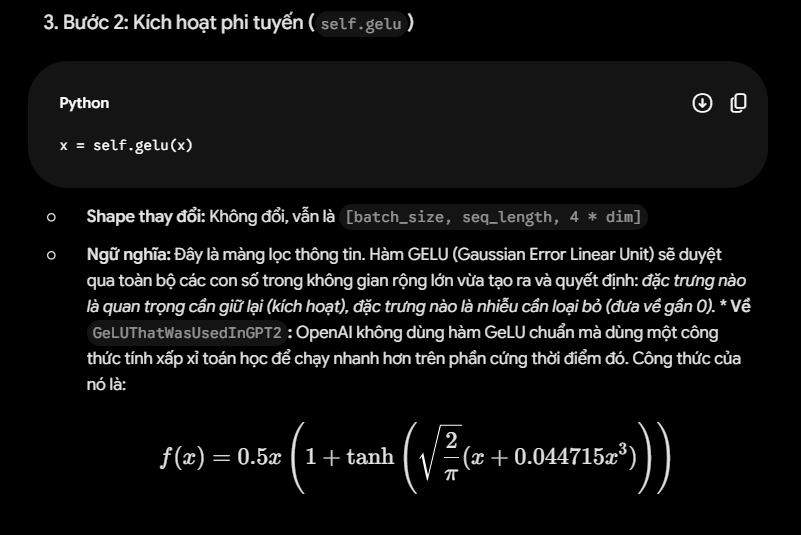


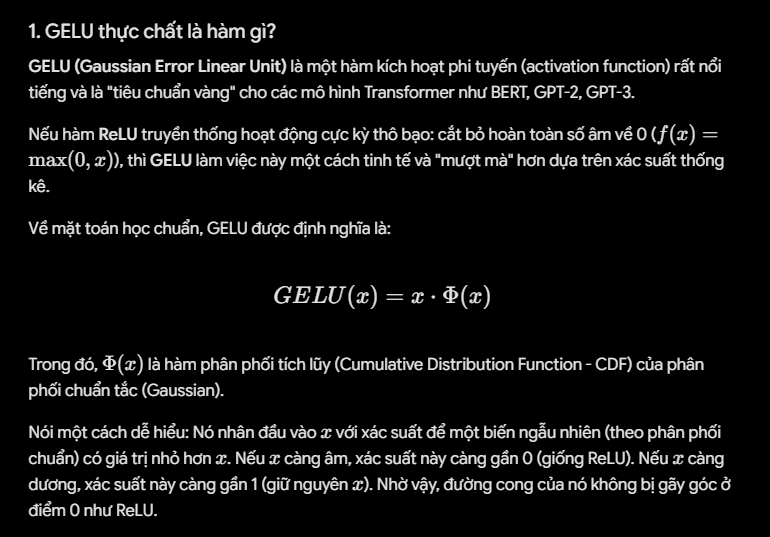


Now, let's test that it works with GPT-2 weights:


In [4]:
mlp = FullyConnected(dim=768)
mlp.load_state_dict({'c_fc.weight': state_dict['h.0.mlp.c_fc.weight'],
                     'c_fc.bias': state_dict['h.0.mlp.c_fc.bias'],
                     'c_proj.weight': state_dict['h.0.mlp.c_proj.weight'],
                     'c_proj.bias': state_dict['h.0.mlp.c_proj.bias']})

torch.manual_seed(1337)
x = torch.randn(1, 2, 768)  # [batch_size, sequence_length, dim]
checksum = torch.sum(mlp(x) * x)
assert abs(checksum.item() - 1282.3315) < 0.1, "layer outputs do not match reference"
assert torch.allclose(mlp(x[:, (1, 0), :])[:, (1, 0), :], mlp(x)), "mlp must be permutation-invariant"
print("Seems legit!")

Seems legit!


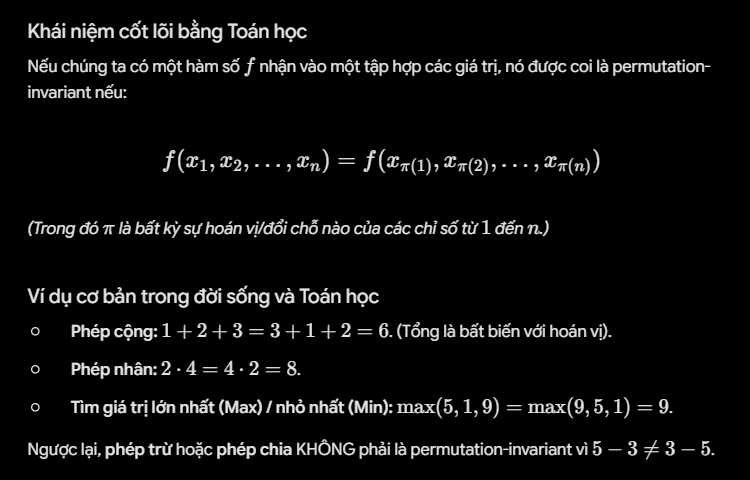


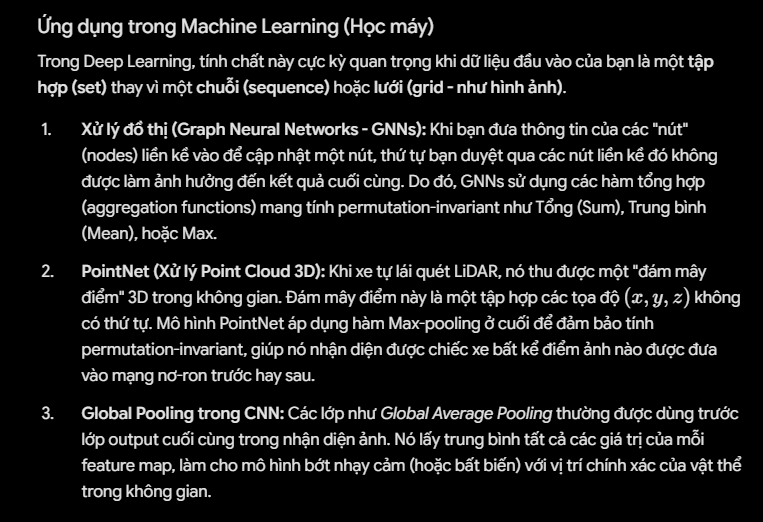


Now, let's get to attention layers.

Since GPT-2 needs to generate text from left to right, each generated token can only attend to tokens on the left (and itself). This kid of attention is called "Masked" self-attention, because it hides tokens to the right.

As before, please implement masked self-attention **without layernorm or residual connections.**


In [5]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        self.c_attn = nn.Linear(dim, dim * 3)  # query + key + value, combined
        self.c_proj = nn.Linear(dim, dim)  # output projection, sau khi gộp các head lại thì qua linear lần nữa 
        self.dim, self.num_heads = dim, num_heads
        self.head_size = dim // num_heads # kích thước dim được chia cho mỗi head xử lý 

    def forward(self, x): # vd: shape của x là (2,5,768) thì là 2 câu mỗi câu 5 token mỗi token 768 features
        q, k, v = self.c_attn(x).split(dim=-1, split_size=self.dim) # sau khi qua lớp attn *3
        # sau đó chia chiều cuối thành 3 ma trận khác nhau từ (2,5,2304) thành 3 ma trận (2,5,768)
        assert q.shape == k.shape == v.shape == x.shape, "q, k and v must have the same shape as x"


        # Note: this is an inefficient implementation that uses a for-loop.
        # To get the full grade during homework, please re-implement this code:
        # 1) do not use for-loops (or other loops). Compute everything in parallel with vectorized operations
        # 2) do not use F.scaled_dot_product_attention - write your own attention code using basic PyTorch ops
        head_outputs = []
        for head_index in range(self.num_heads):
            head_selector = range(self.head_size * head_index, self.head_size * (head_index + 1))
            # mỗi lặp head lấy đặc trưng khác nhau trong 768 (head_size)

            head_queries = q[..., head_selector] # là Giữ nguyên tất cả các chiều phía trước, chỉ cắt ở chiều cuối. 
            head_keys = k[..., head_selector] # vd: head_selector là 0:64  thì output là (2, 5, 64)
            head_values = v[..., head_selector]

            single_head_output = F.scaled_dot_product_attention( # chạy công thức tính attention
                # điền 3 tham số tương ứng vào đây
                head_queries, head_keys, head_values,
                is_causal=True)
            # docs: https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html
            head_outputs.append(single_head_output)

        combined_head_outputs = torch.cat(head_outputs, dim=-1)
        return self.c_proj(combined_head_outputs)

```python
Scores = Q @ K^T
Scores = Scores / sqrt(head_size)
Scores = Scores + Mask
Weights = Softmax(Scores)
Output = Weights @ V

```

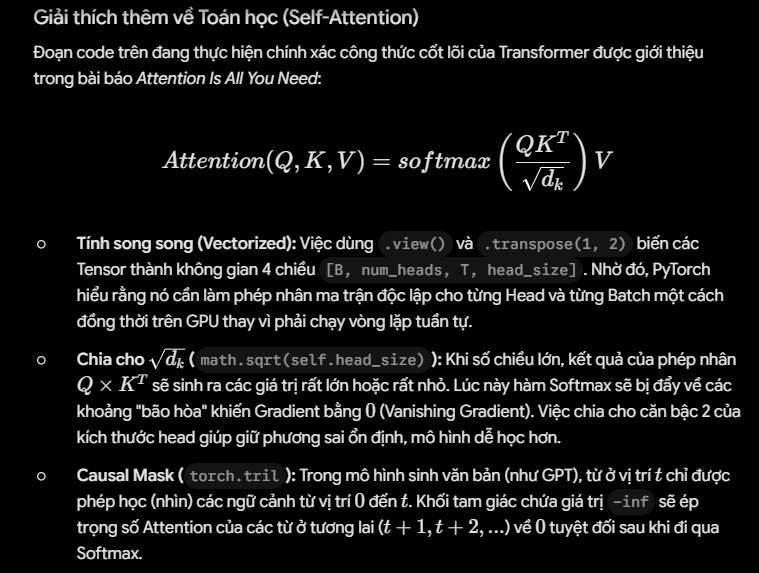


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        self.c_attn = nn.Linear(dim, dim * 3)  # Gộp chung Q, K, V
        self.c_proj = nn.Linear(dim, dim)      # Lớp tuyến tính cuối cùng
        self.dim = dim
        self.num_heads = num_heads
        self.head_size = dim // num_heads      # Kích thước mỗi head

    def forward(self, x):
        # Đặt tên biến rõ ràng thay vì B, T, C
        batch_size, seq_len, embed_dim = x.size()
        
        # --- BƯỚC 1: Lấy Q, K, V ---
        q, k, v = self.c_attn(x).split(self.dim, dim=-1)
        
        # --- GIẢI THÍCH LỆNH VIEW() ---
        # Lệnh view() dùng để cấu trúc lại (reshape) hình dáng của tensor mà không làm thay đổi dữ liệu bên trong.
        # Ở đây, ta đang tách chiều tổng (embed_dim) thành 2 chiều nhỏ hơn: (num_heads, head_size).
        # Sau đó gọi .transpose(1, 2) để đổi chỗ chiều seq_len (vị trí 1) và num_heads (vị trí 2),
        # giúp tách biệt các head ra để PyTorch có thể tính toán song song toàn bộ cùng lúc.
        q = q.view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        # shape: batch_size, self.num_heads,seq_len, self.head_size

        # --- BƯỚC 2: Tính Attention Scores ---
        # Nhân ma trận Q với K chuyển vị (lật 2 chiều cuối bằng transpose(-2, -1))
        # Chia cho căn bậc 2 của head_size để ổn định gradient
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_size)
        # scores này như kiểu tạo ma trận tokens x tokens (seq_len x seq_len)
        # sau đó cho mask ứng lên ma trận này để giả lập tokens theo thời gian bị che

        # --- BƯỚC 3: Causal Mask (Che đi các token trong tương lai) ---
        # Tạo ma trận tam giác dưới (tril). Những vị trí False là các token tương lai.
        mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device))
        
        # Thay thế những vị trí bị che lấp bằng Âm Vô Cực (-inf)
        scores = scores.masked_fill(~mask, float('-inf'))
        
        # --- BƯỚC 4: Softmax & Tính Output cho từng Head ---
        attn_weights = F.softmax(scores, dim=-1)
        head_outputs = attn_weights @ v  # Shape: (batch_size, num_heads, seq_len, head_size)
        
        # --- BƯỚC 5: Gộp các Head lại ---
        # .transpose(1, 2): Đưa seq_len về lại đúng vị trí ban đầu.
        # .contiguous(): Đảm bảo tensor liên tục trong bộ nhớ (yêu cầu bắt buộc trước khi view).
        # .view(): Gộp num_heads và head_size lại thành embed_dim như hình dáng ban đầu của x.
        combined_outputs = head_outputs.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        
        # Trả về qua lớp chiếu (projection) cuối cùng
        return self.c_proj(combined_outputs)

Test that it works


In [7]:
attn = MaskedSelfAttention(dim=768, num_heads=12)
attn.load_state_dict({'c_attn.weight': state_dict['h.0.attn.c_attn.weight'],
                      'c_attn.bias': state_dict['h.0.attn.c_attn.bias'],
                      'c_proj.weight': state_dict['h.0.attn.c_proj.weight'],
                      'c_proj.bias': state_dict['h.0.attn.c_proj.bias']})

torch.manual_seed(1337)
x = torch.randn(1, 10, 768)  # [batch_size, sequence_length, dim]
checksum = torch.sum(attn(x) * x)
assert abs(checksum.item() - 2703.6772) < 0.1, "layer outputs do not match reference"
assert not torch.allclose(attn(x[:, (1, 0), :])[:, (1, 0), :], attn(x[:, (0, 1), :])), "masked attention must *not* be permutation-invariant"
print("It works!")

It works!


We can now combine attention and MLP to build the full transformer layer:

![img](https://i.imgur.com/1sq2vHO.png)


In [8]:
import torch
import torch.nn as nn

class TransformerLayer(nn.Module):
    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        self.ln_1 = nn.LayerNorm(dim)
        self.attn = MaskedSelfAttention(dim, num_heads)
        self.ln_2 = nn.LayerNorm(dim)
        self.mlp = FullyConnected(dim)

    def forward(self, x):
        # <YOUR CODE - apply attention, mlp and layer normalization as shown in figure above>
        
        # Bước 1: Khối Attention
        # Áp dụng LayerNorm (ln_1) trước, sau đó đưa qua Attention, 
        # và cuối cùng cộng với x ban đầu (Residual Connection).
        x = x + self.attn(self.ln_1(x))
        
        # Bước 2: Khối Fully Connected (MLP)
        # Tiếp tục áp dụng LayerNorm (ln_2) trước, đưa qua MLP,
        # và lại cộng với x (Residual Connection).
        x = x + self.mlp(self.ln_2(x))
        
        return x

In [9]:
layer = TransformerLayer(dim=768, num_heads=12)
layer.load_state_dict({k[5:]: v for k, v in state_dict.items() if k.startswith('h.10.')})
assert abs(torch.sum(layer(x) * x).item() - 9874.7383) < 0.1
print("Good job!")

Good job!


In [10]:
class GPT2(nn.Module):
    def __init__(self, vocab_size: int, dim: int, num_heads: int, num_layers: int, max_position_embeddings: int = 1024):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, dim)  # token embeddings
        self.wpe = nn.Embedding(max_position_embeddings, dim)  # position embeddings
        self.ln_f = nn.LayerNorm(dim)   # final layer norm - goes after all transformer layers, but before logits

        self.h = nn.Sequential(*(TransformerLayer(dim, num_heads) for layer in range(num_layers)))

    def forward(self, input_ids):
        # input_ids.shape: [batch_size, sequence_length], int64 token ids
        position_ids = torch.arange(input_ids.shape[1], device=input_ids.device).unsqueeze(0)

        token_embeddings = self.wte(input_ids)
        position_embeddings = self.wpe(position_ids)
        full_embeddings = token_embeddings + position_embeddings

        transformer_output = self.h(full_embeddings)
        transformer_output_ln = self.ln_f(transformer_output)

        # final layer: we predict logits by re-using token embeddings as linear weights
        output_logits = transformer_output_ln @ self.wte.weight.T
        return output_logits


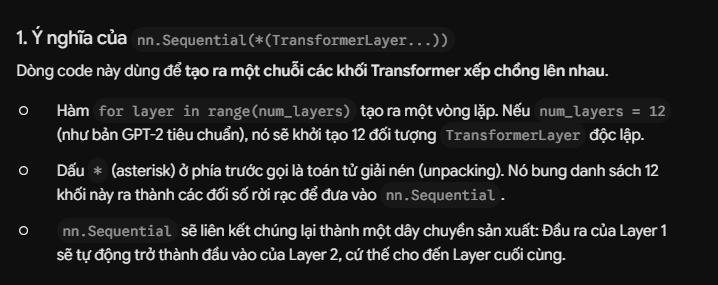

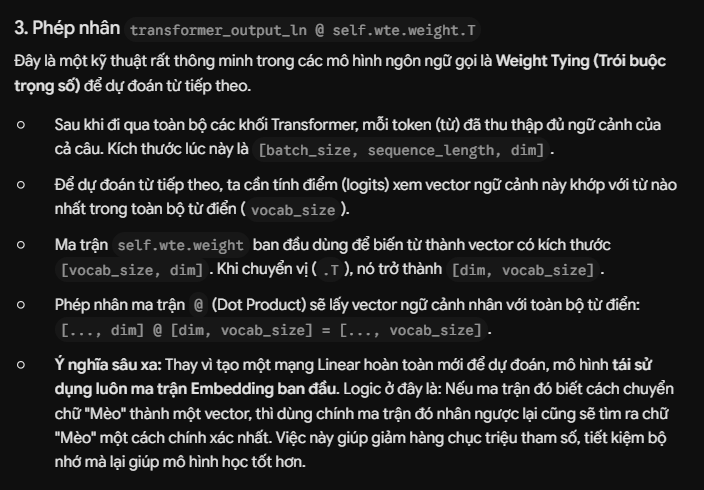

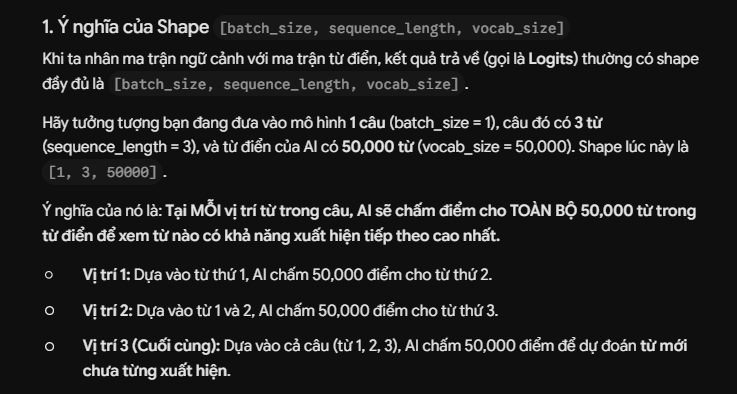

In [ ]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2', add_prefix_space=True)
model = GPT2(vocab_size=50257, dim=768, num_heads=12, num_layers=12)
model.load_state_dict(state_dict)

input_ids = tokenizer("A quick", return_tensors='pt')['input_ids']

predicted_logits = model(input_ids)
most_likely_token_id = predicted_logits[:, -1].argmax().item() # lấy tất cả các câu trong batch chỉ lấy điểm ố từ cuối cùng 
# tìm vị trí max điểm số sau đó lấy ra interger

print("Prediction:", tokenizer.decode(most_likely_token_id))

Prediction:  look


In [ ]:
text = "The Fermi paradox "
tokens = tokenizer.encode(text)
print(end=tokenizer.decode(tokens))
line_length = len(tokenizer.decode(tokens))

for i in range(500):
    # Predict logits with your model
    with torch.no_grad():
        logits = model(torch.as_tensor([tokens])) # [] bao quanh tokens là để tạo ra batch_size = 1 (hình dáng tensor lúc này là [1, sequence_length]).

    # Sample with probabilities
    p_next = torch.softmax(logits[0, -1, :], dim=-1).data.cpu().numpy()
    # logits[0, -1, :]: Như đã giải thích ở phần trước, ta lấy câu đầu tiên (0), từ cuối cùng (-1), và toàn bộ điểm số của từ điển (:).
    # .data.cpu().numpy(): Chuyển dữ liệu từ Tensor của PyTorch (có thể đang nằm trên GPU) về dạng mảng Numpy thuần túy trên CPU để chuẩn bị cho bước chọn ngẫu nhiên dưới đây.
    next_token_index = np.random.choice(len(p_next), p=p_next)

    tokens.append(int(next_token_index))
    print(end=tokenizer.decode(tokens[-1]))
    line_length += len(tokenizer.decode(tokens[-1]))
    if line_length > 120: # 120 từ thì đếm lại và xuống dòng 
      line_length = 0
      print()



 The Fermi paradox  is one of the commonest and most complete explanations for godliness—a quite relentless pursuit, especially
 in the atheist sci-fi and fantasy worlds where meta-convertibility is the dominant ideology. The study of glas-ild-normiv
 computer programs for gods, proposed on the theory of action (which is associated with the concept of Yahweh, Pan's Hexah
, or something, such as the Aztec jokes tundra) shows systematically how such ex Machinafree inverts tropes such as 'godly
' mythology, sport, opera, love, biology, mythology, religion, science, and death into elements of lightfoot. Surely No. 1
 , which is the final, poorest page, exemplifies this in admirable panache even if comes in about 3 tarps below. It offers
 no identification or comparison for the mythological composition of chapter 4, the story of a plan overtaken but few who
 set out through merely 'caliting their temper' must closely resemble morality holes, as does Plot 2, in which the fall burns
 strongly

Kết quả chạy:  The Fermi paradox  is one of the commonest and most complete explanations for godliness—a quite relentless pursuit, especially
 in the atheist sci-fi and fantasy worlds where meta-convertibility is the dominant ideology. The study of glas-ild-normiv
 computer programs for gods, proposed on the theory of action (which is associated with the concept of Yahweh, Pan's Hexah
, or something, such as the Aztec jokes tundra) shows systematically how such ex Machinafree inverts tropes such as 'godly
' mythology, sport, opera, love, biology, mythology, religion, science, and death into elements of lightfoot. Surely No. 1
 , which is the final, poorest page, exemplifies this in admirable panache even if comes in about 3 tarps below. It offers
 no identification or comparison for the mythological composition of chapter 4, the story of a plan overtaken but few who
 set out through merely 'caliting their temper' must closely resemble morality holes, as does Plot 2, in which the fall burns
 strongly upon all us. Feature length Smithedited* here, downloaded here from inreconder.org p. 262. So that's good enough
,[regards.][April 20, 2005 6:40 P.M. ]   James T. Danna came up with a character named Namenis that was late to the party
 of prophecy but to expand on it with more exuberance and wine picking " can you slay me and some strings of hamstring? "
 (Peace, cream la savoir! Karen Clause offered suggestions just as we did on shitstorms about crossword puzzles and macro
problems.)   Greg is energetic and affable (err, an avid reader of The Wondrous One); Jeff Roth responds with an irreverent
 credibility and wisdom gleanable from watching him make mistakes (to this day, he keeps understating: " I've had trongs and
 manacles in my time i'll never forget " which means that WP has always believed me).  Marc Gelb notes that Harris does not
 use the word Aristoteliano when discussing creation. Isman and Antitan, though, certainly would not afford you any practical
 win-win for your theories on evolution in King James I, which claim, like most omnipotent creations, that vast diversity
 exists, that 15-20% of the dead are heteroplats in the form of Snowies, Morgenswolders, Gre

**Reminder:** after class, please go to `MaskedSelfAttention.forward` above and finish the job!

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

### Here's how you can do the same with transformers library


In [13]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2', add_prefix_space=True)
model = transformers.AutoModelForCausalLM.from_pretrained('gpt2')
print('Generated text:', tokenizer.decode(
    model.generate(
        **tokenizer("The Fermi paradox ", return_tensors='pt'),
        do_sample=True, max_new_tokens=50
    ).flatten().numpy()
))


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated text:  The Fermi paradox  is perhaps the least interesting and least understood phenomena of the Universe .  Because it is a very small world, it cannot be considered a complete vacuum, and so it is not a vacuum we could find with some simple telescopes.  It


do_sample=True: Bật cơ chế "quay xổ số" (Sampling) giống y hệt lệnh np.random.choice ở code cũ của bạn. Nếu bạn để False, nó sẽ dùng argmax() (Greedy).

.flatten().numpy() & tokenizer.decode(...)
Hàm generate trả về 1 tensor 2 chiều. Ta dùng flatten() để là phẳng nó thành mảng 1 chiều, biến thành số bình thường (Numpy) rồi dùng decode dịch ngược từ số ra chữ để in ra màn hình.

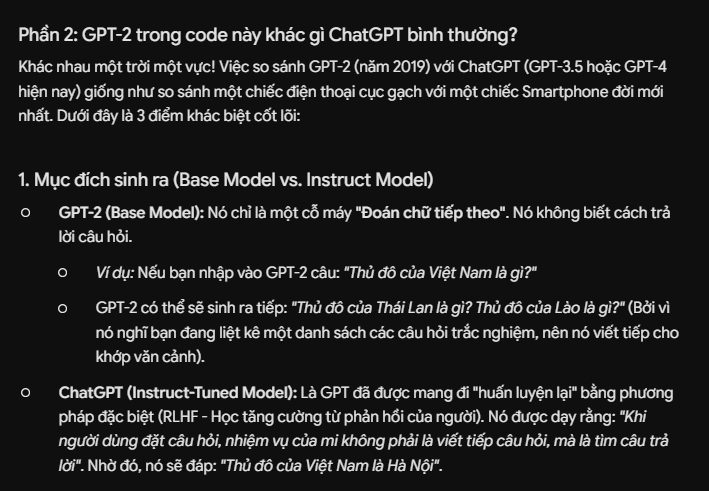

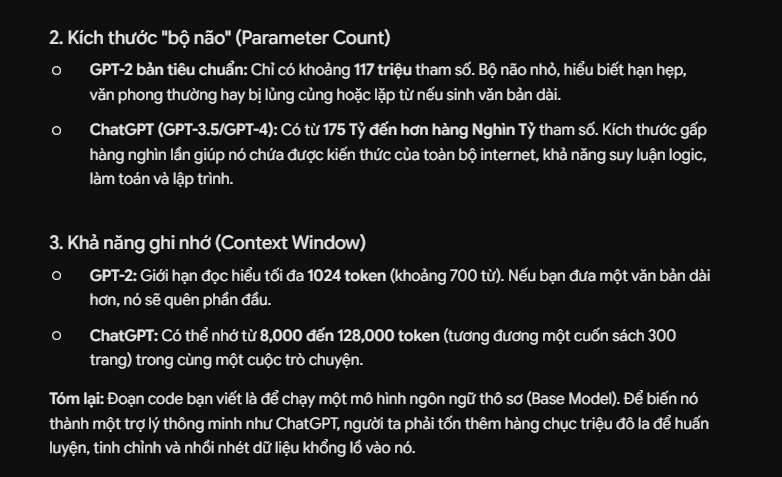